# Rate of Return distribution

The distribution of the below equation is normal.
$$\log \bigg(\frac{x_{i}}{x_{i - 1}}\bigg)$$

Since we know that 
$$dS = \mu S dt + \sigma S dW$$

We can apply Ito's lemma to find the distribution of the log returns. Let $f(S) = \log(S)$, then we have:
$$df = f'(S) dS + \frac{1}{2} f''(S) (dS)^2$$
Calculating the derivatives, we get:
$$f'(S) = \frac{1}{S}$$
$$f''(S) = -\frac{1}{S^2}$$
Substituting these into the equation, we have:
$$df = \frac{1}{S} (\mu S dt + \sigma S dW) + \frac{1}{2} \left(-\frac{1}{S^2}\right) (\sigma^2 S^2 dt)$$
Simplifying this, we get:
$$df = \left(\mu - \frac{1}{2} \sigma^2\right) dt + \sigma dW$$
This shows that the log returns follow a normal distribution with mean $\mu - \frac{1}{2} \sigma^2$ and variance $\sigma^2$. Therefore, the distribution of the log returns is normal.

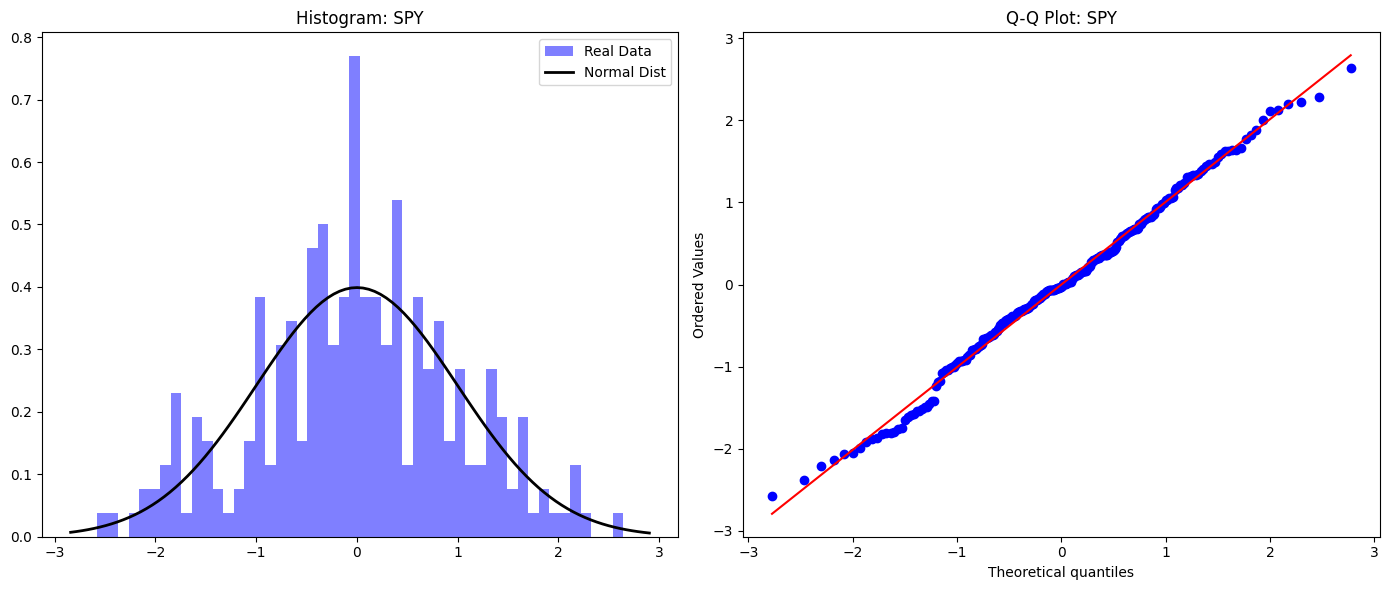

Kurtosis: -0.18 (Normal = 0.0)
Normality test p-value: 0.8615
Shapiro-Wilk test p-value: 0.4115


In [2]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Get Real Data
ticker = "SPY"
data = yf.download(ticker, start="2023-01-01", end="2023-12-31", progress=False)

# CHECK 1: Did we actually get data?
if len(data) < 5:
    print(f"Error: Not enough data downloaded for {ticker}. Check ticker symbol or date range.")
else:
    # Use Adjusted Close
    prices = data['Close']

    # 2. Calculate Log Returns
    # Note: We convert to numpy immediately to avoid pandas index issues
    log_returns = np.log(prices / prices.shift(1)).dropna().values.flatten()

    # 3. Standardize (Z-scores)
    # CHECK 2: Handle constant prices (std = 0)
    if np.std(log_returns) == 0:
        print("Error: Stock price never changed. Variance is zero.")
    else:
        z_scores = (log_returns - np.mean(log_returns)) / np.std(log_returns)

        # CHECK 3: Remove potential Infs or NaNs created during division
        z_scores = z_scores[np.isfinite(z_scores)]

        if len(z_scores) > 0:
            # 4. Generate the Plots
            plt.figure(figsize=(14, 6))

            # Histogram
            plt.subplot(1, 2, 1)
            plt.hist(z_scores, bins=50, density=True, alpha=0.5, color='blue', label='Real Data')
            
            # Theoretical Normal
            xmin, xmax = plt.xlim()
            x = np.linspace(xmin, xmax, 100)
            p = stats.norm.pdf(x, 0, 1)
            plt.plot(x, p, 'k', linewidth=2, label='Normal Dist')
            plt.title(f"Histogram: {ticker}")
            plt.legend()

            # Q-Q Plot
            plt.subplot(1, 2, 2)
            stats.probplot(z_scores, dist="norm", plot=plt)
            plt.title(f"Q-Q Plot: {ticker}")

            plt.tight_layout()
            plt.show()
            
            # Kurtosis Check
            k = stats.kurtosis(z_scores)
            print(f"Kurtosis: {k:.2f} (Normal = 0.0)")

            _, p_value = stats.normaltest(z_scores)
            print(f"Normality test p-value: {p_value:.4f}")

            _, shapiro_p = stats.shapiro(z_scores)
            print(f"Shapiro-Wilk test p-value: {shapiro_p:.4f}")
        else:
            print("Error: Data cleaning resulted in empty array.")